<a href="https://www.kaggle.com/code/lalit7881/bank-fraud-detection-analytics-eda?scriptVersionId=319718009" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset/banking_transactions.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset/banking_transactions.csv")

In [3]:
df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [4]:
df.tail()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
9995,1009996,3552.90,1,36.6,21,0.16,1315,21,12,17919.66,117,14829,36,75.4,Mobile App,Password Only,0,0,1,False
9996,1009997,21559.69,11,14.4,28,0.26,4644,22,11,8477.85,15,10795,63,10.8,POS Terminal,Two-Factor Authentication,0,1,1,False
9997,1009998,4181.33,1,84.0,50,0.23,262,3,3,272564.27,60,3840,91,93.3,Mobile App,Biometric,0,1,1,False
9998,1009999,21443.71,3,33.8,44,0.01,255,4,14,142791.28,116,10110,42,87.1,Mobile App,OTP,1,1,1,False
9999,1010000,24974.25,12,0.0,4,0.87,532,1,19,367234.24,104,7202,102,14.9,POS Terminal,Biometric,0,1,1,True


In [5]:
df.isnull()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [10]:
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


In [11]:
df.dtypes

transaction_id                      int64
transaction_amount                float64
login_attempts                      int64
device_risk_score                 float64
transfer_frequency                  int64
anomaly_score                     float64
account_age_days                    int64
transaction_time_hour               int64
failed_transactions_last_30d        int64
avg_monthly_balance               float64
daily_transaction_count             int64
geo_distance_km                     int64
session_duration_minutes            int64
transaction_velocity_score        float64
payment_channel                    object
authentication_type                object
card_present_flag                   int64
international_transaction_flag      int64
suspicious_ip_flag                  int64
fraud_flag                           bool
dtype: object

In [12]:
df.shape

(10000, 20)

In [13]:
df.nunique()

transaction_id                    10000
transaction_amount                 9981
login_attempts                       12
device_risk_score                  1001
transfer_frequency                   81
anomaly_score                        99
account_age_days                   4339
transaction_time_hour                24
failed_transactions_last_30d         26
avg_monthly_balance                9997
daily_transaction_count             120
geo_distance_km                    7323
session_duration_minutes            120
transaction_velocity_score         1001
payment_channel                       4
authentication_type                   4
card_present_flag                     2
international_transaction_flag        2
suspicious_ip_flag                    2
fraud_flag                            2
dtype: int64

## EDA

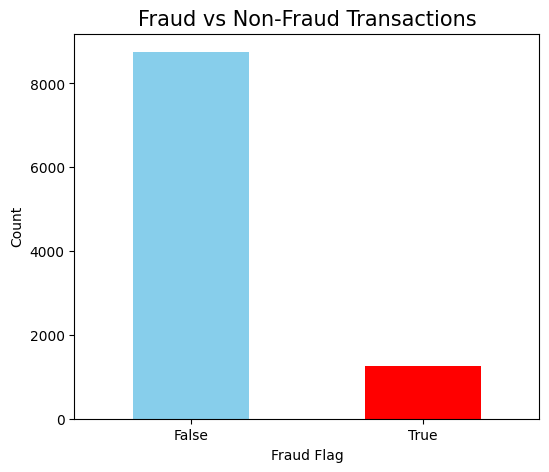

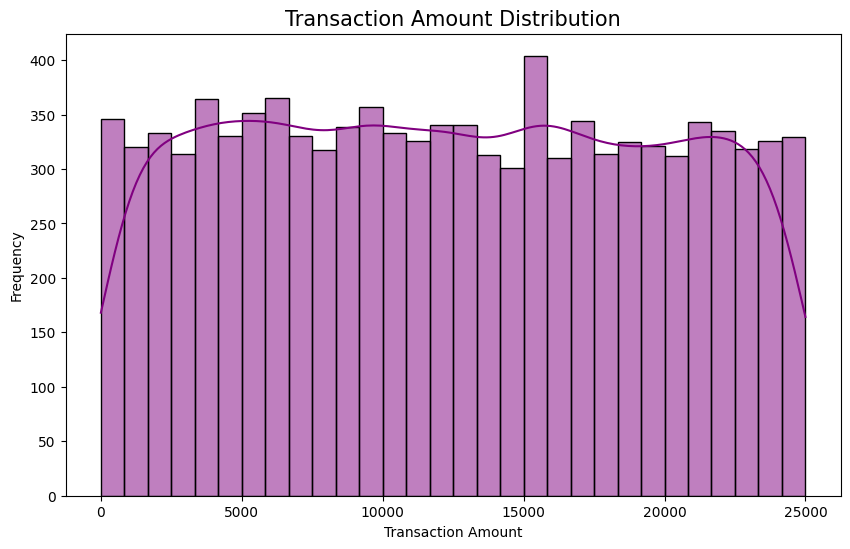

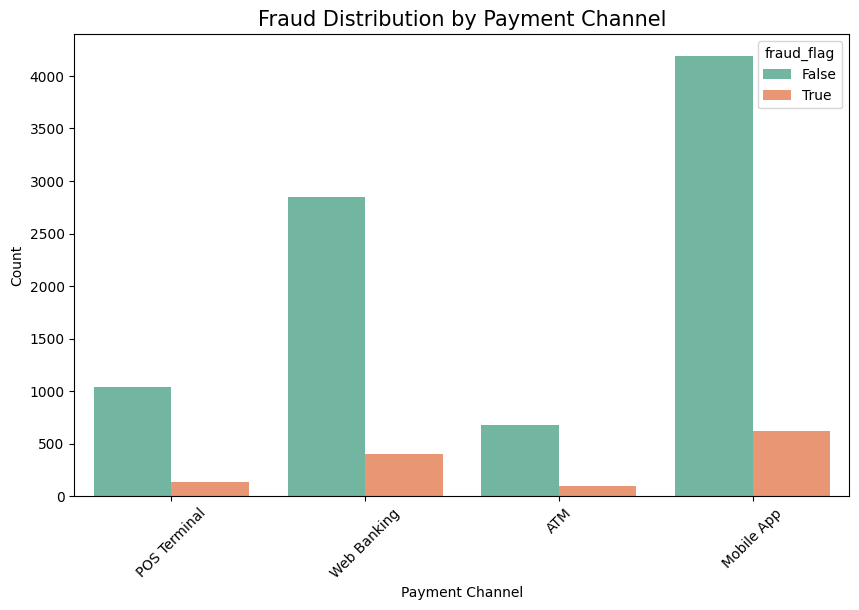

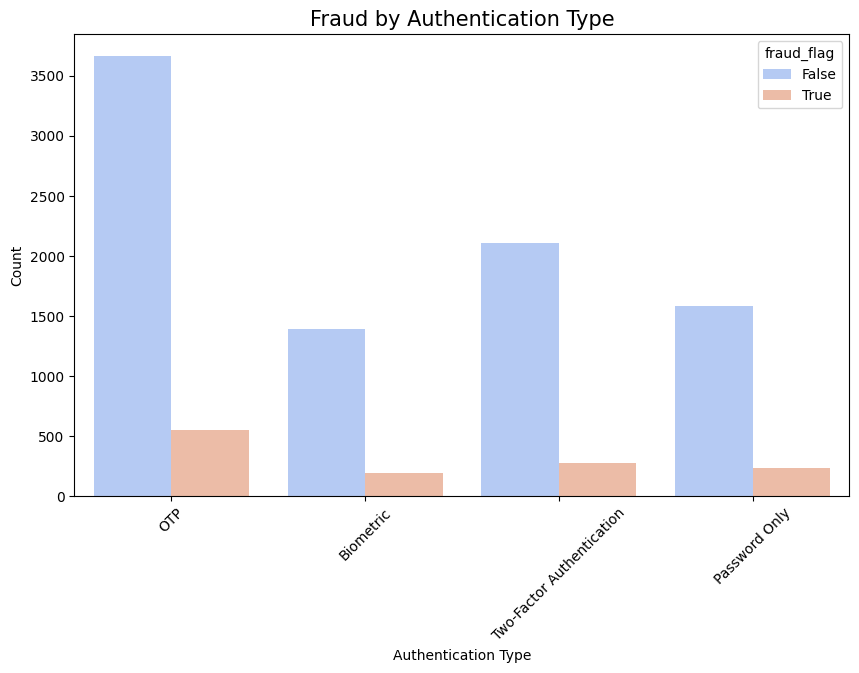

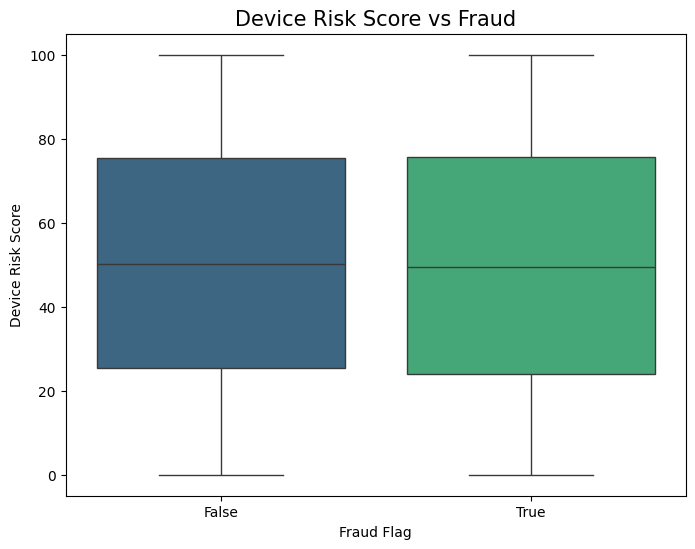

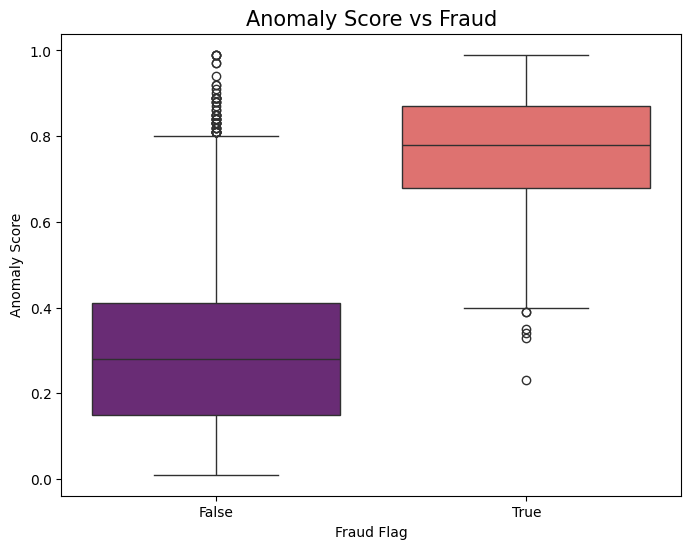

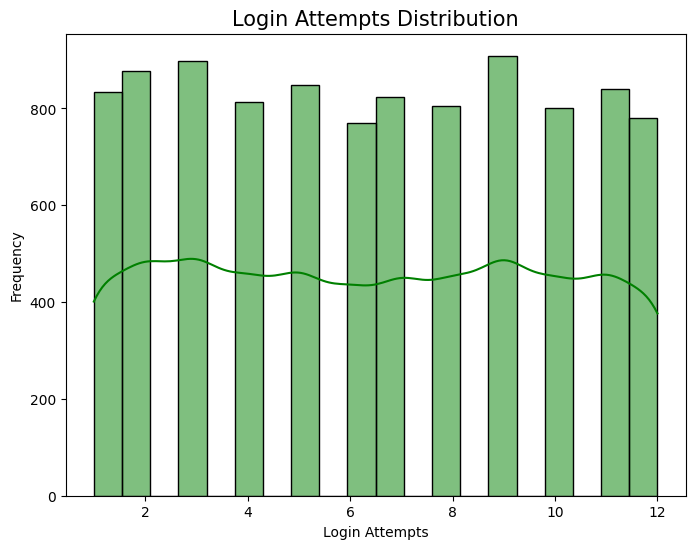

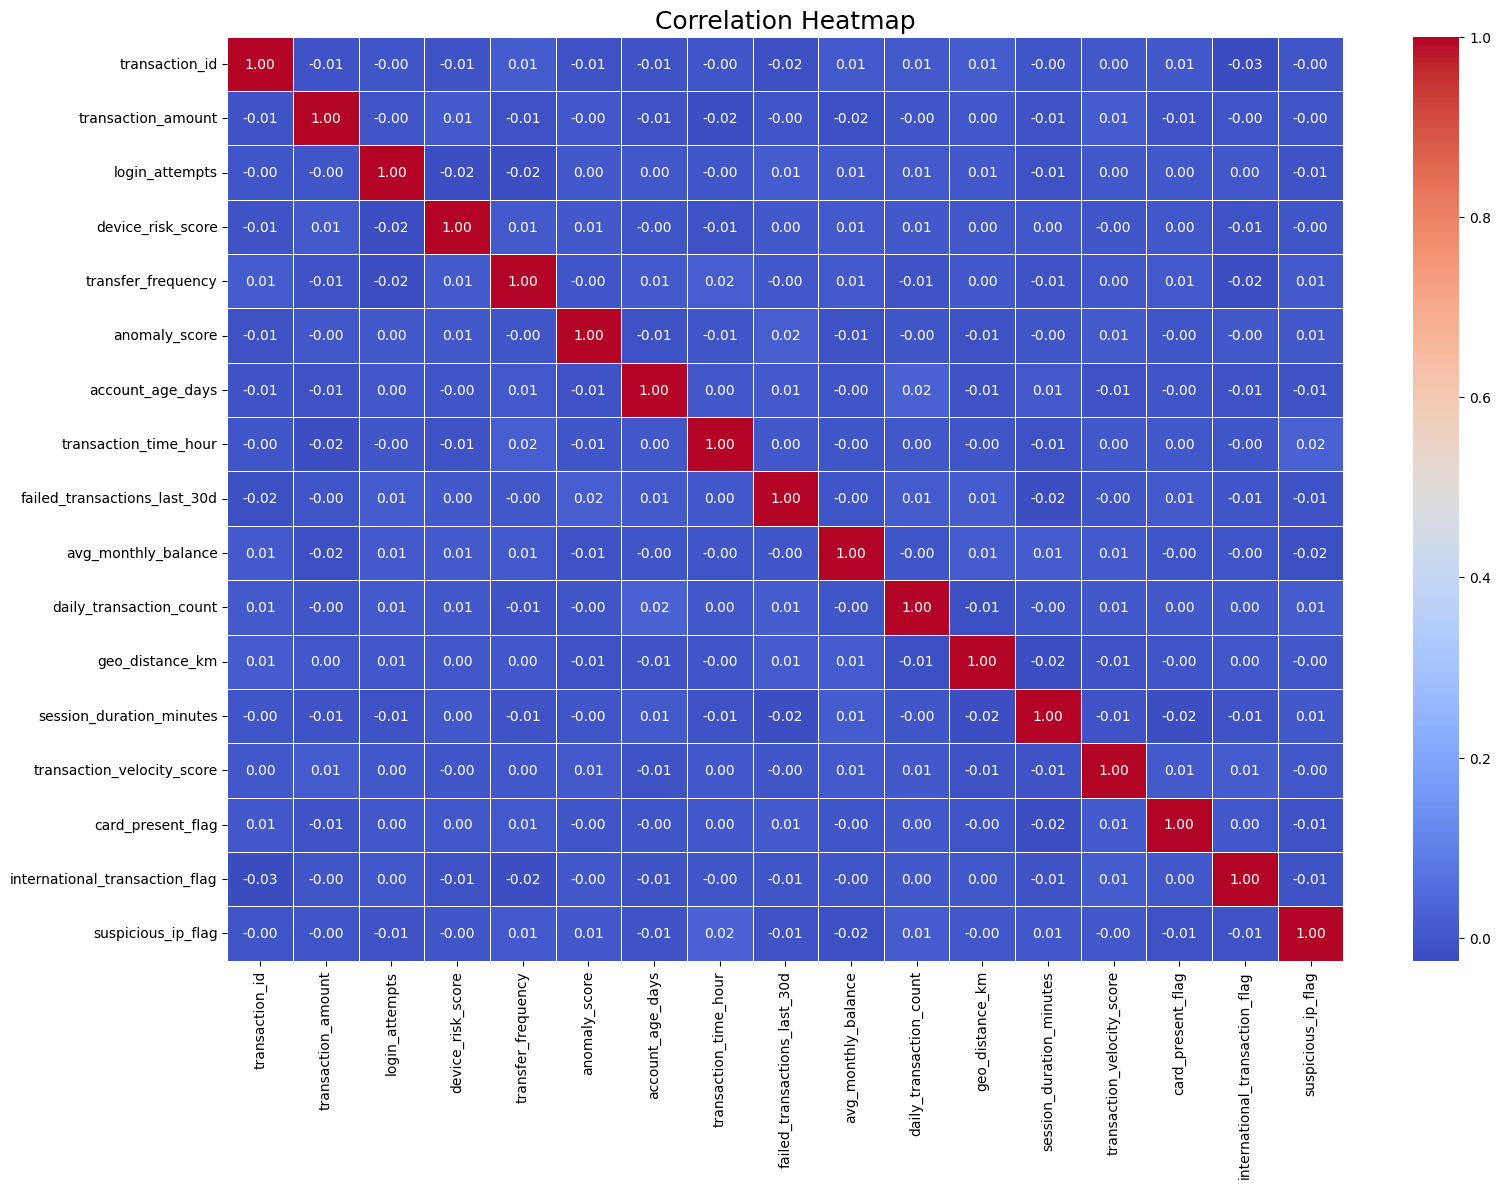

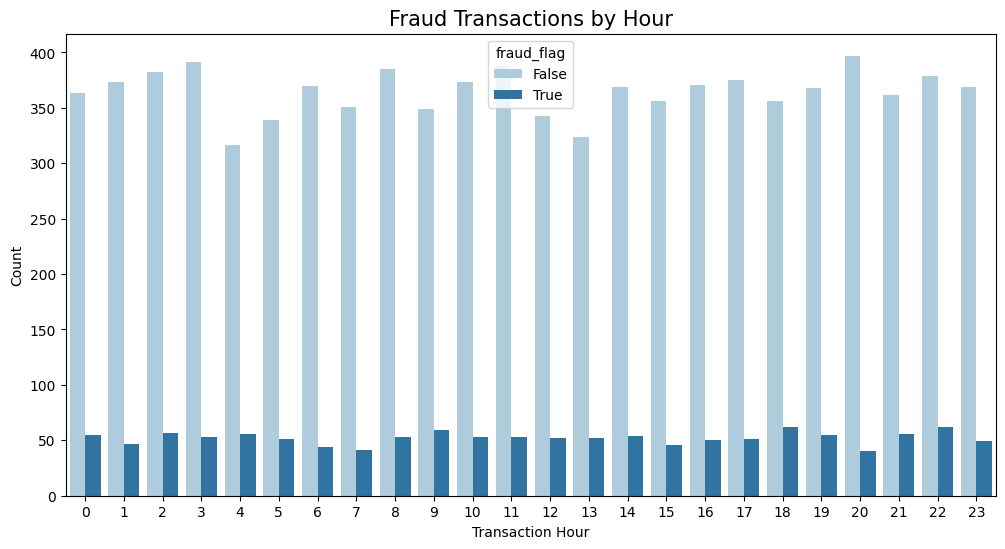

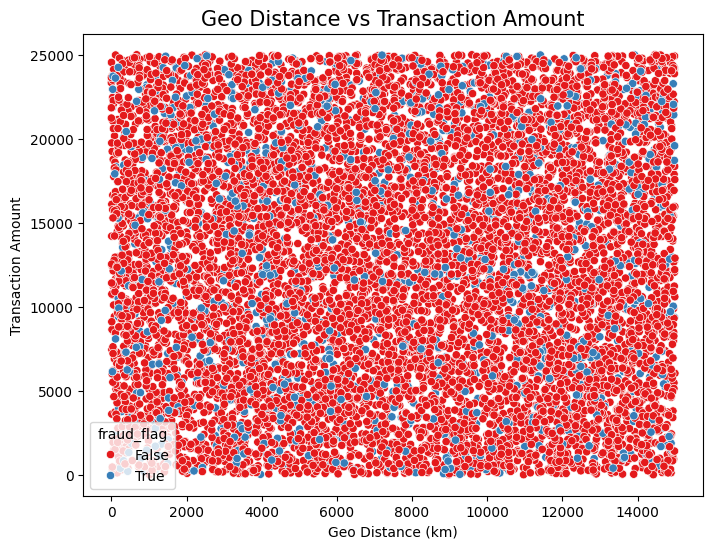

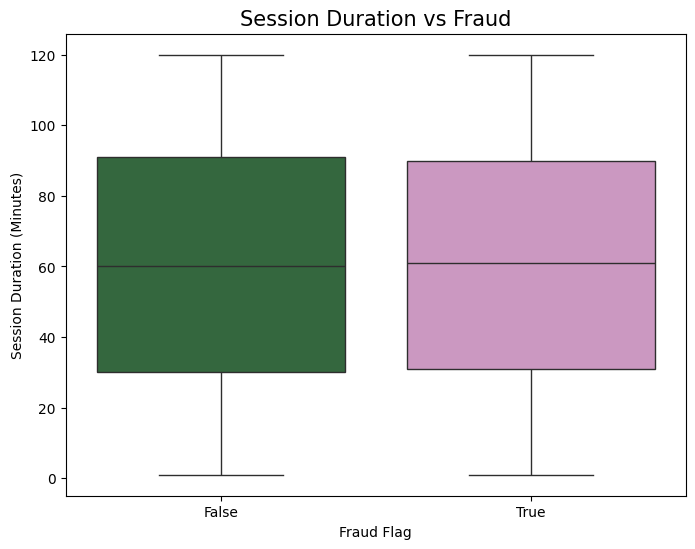

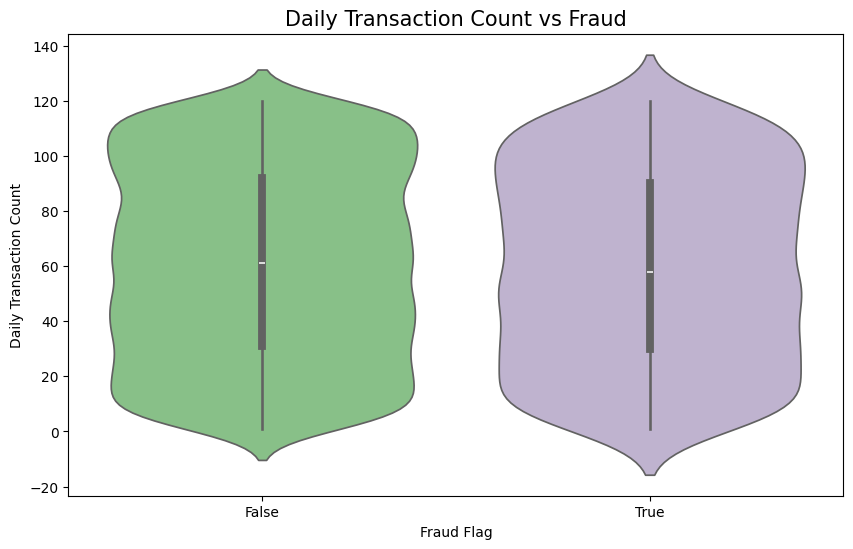

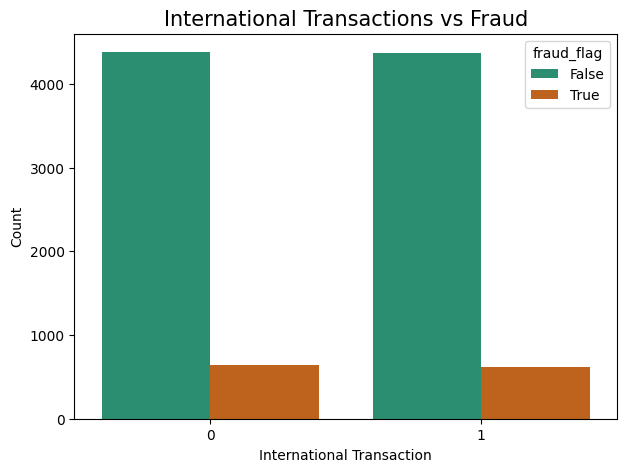

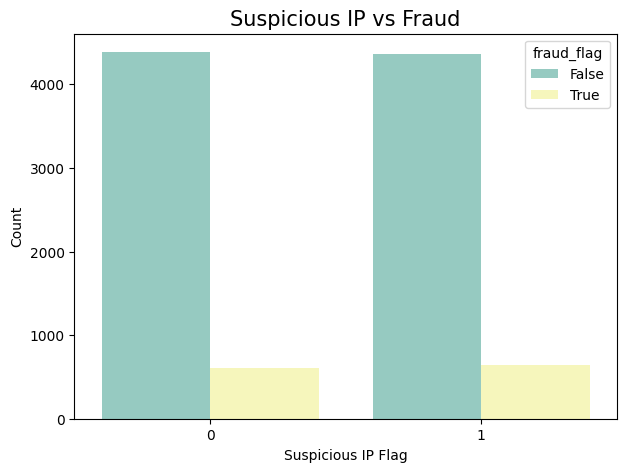

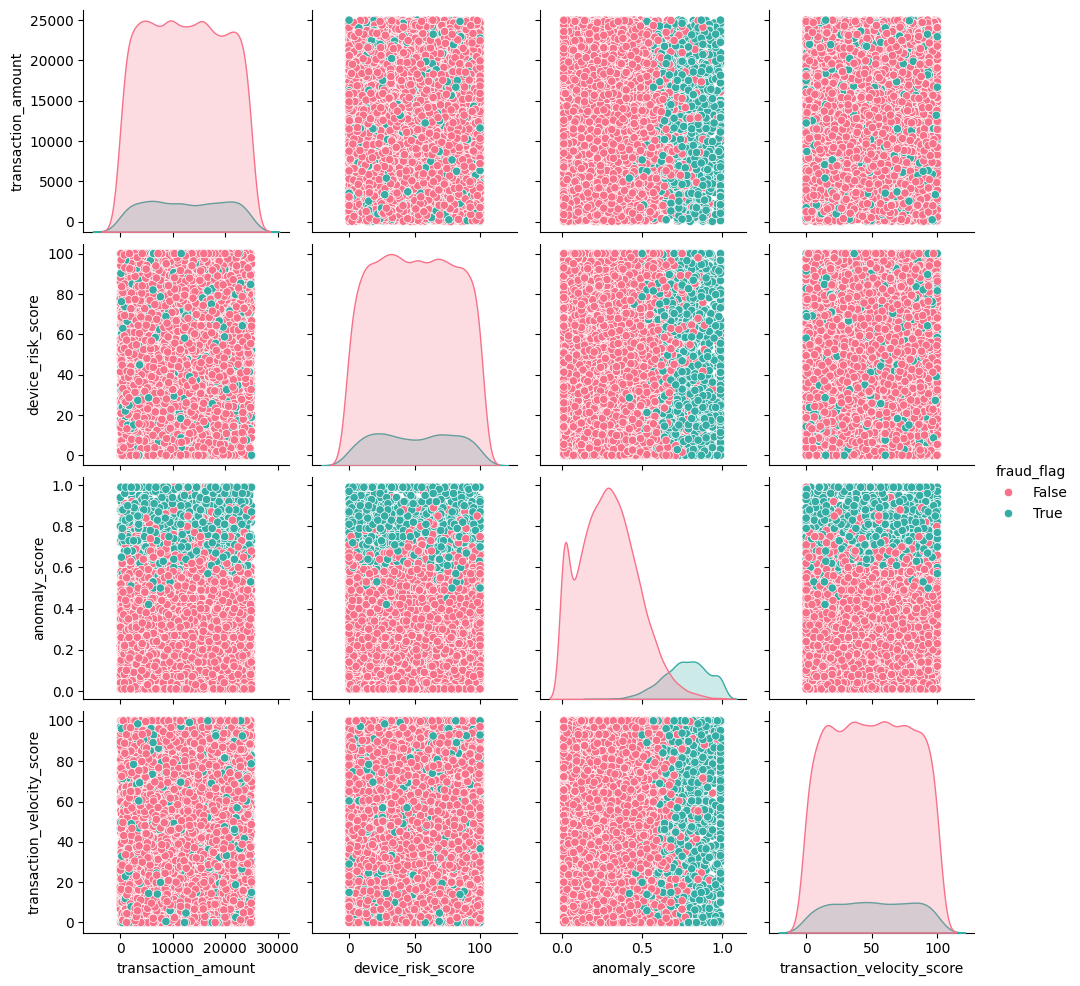

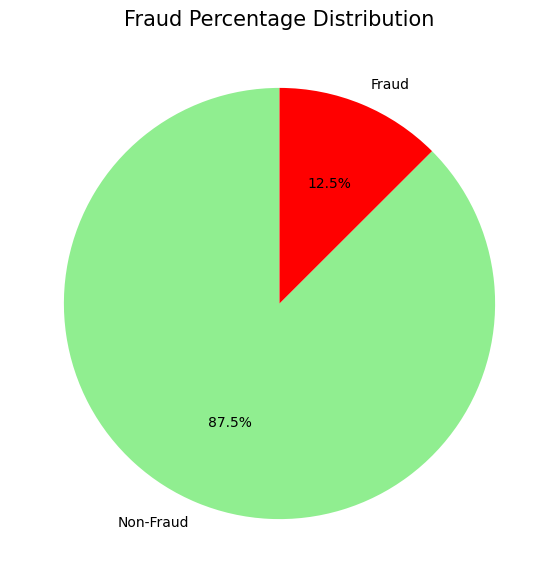

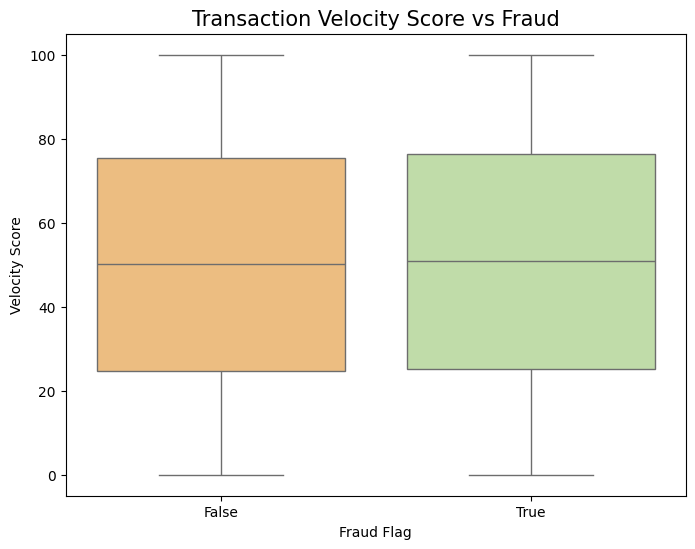

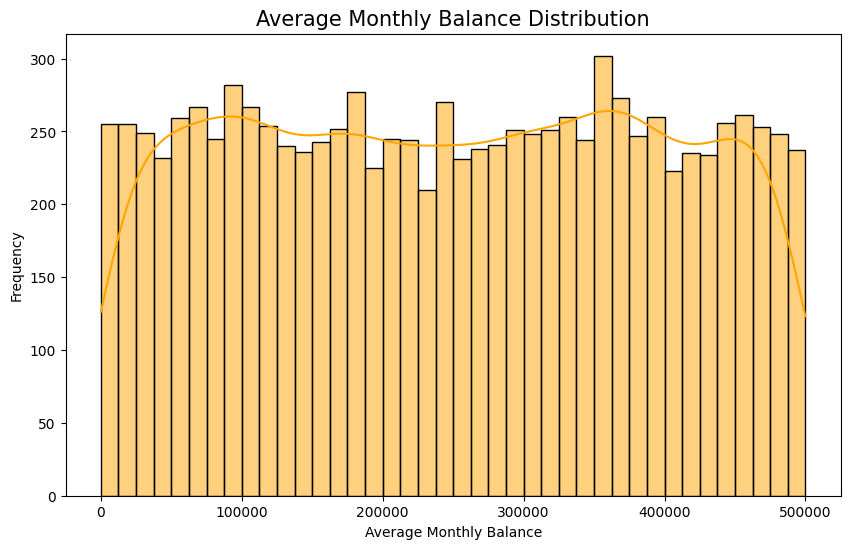

In [14]:
# =========================
# 1. Fraud Distribution
# =========================
plt.figure(figsize=(6,5))
colors = ['skyblue', 'red']

df['fraud_flag'].value_counts().plot(
    kind='bar',
    color=colors
)

plt.title("Fraud vs Non-Fraud Transactions", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# =========================
# 2. Transaction Amount Distribution
# =========================
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='transaction_amount',
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Transaction Amount Distribution", fontsize=15)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

# =========================
# 3. Fraud by Payment Channel
# =========================
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='payment_channel',
    hue='fraud_flag',
    palette='Set2'
)

plt.title("Fraud Distribution by Payment Channel", fontsize=15)
plt.xlabel("Payment Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================
# 4. Fraud by Authentication Type
# =========================
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='authentication_type',
    hue='fraud_flag',
    palette='coolwarm'
)

plt.title("Fraud by Authentication Type", fontsize=15)
plt.xlabel("Authentication Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================
# 5. Device Risk Score vs Fraud
# =========================
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='fraud_flag',
    y='device_risk_score',
    palette='viridis'
)

plt.title("Device Risk Score vs Fraud", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Device Risk Score")
plt.show()

# =========================
# 6. Anomaly Score vs Fraud
# =========================
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='fraud_flag',
    y='anomaly_score',
    palette='magma'
)

plt.title("Anomaly Score vs Fraud", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Anomaly Score")
plt.show()

# =========================
# 7. Login Attempts Distribution
# =========================
plt.figure(figsize=(8,6))

sns.histplot(
    df['login_attempts'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Login Attempts Distribution", fontsize=15)
plt.xlabel("Login Attempts")
plt.ylabel("Frequency")
plt.show()

# =========================
# 8. Correlation Heatmap
# =========================

# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# =========================
# 9. Transaction Time Analysis
# =========================
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='transaction_time_hour',
    hue='fraud_flag',
    palette='Paired'
)

plt.title("Fraud Transactions by Hour", fontsize=15)
plt.xlabel("Transaction Hour")
plt.ylabel("Count")
plt.show()

# =========================
# 10. Geo Distance vs Fraud
# =========================
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='geo_distance_km',
    y='transaction_amount',
    hue='fraud_flag',
    palette='Set1'
)

plt.title("Geo Distance vs Transaction Amount", fontsize=15)
plt.xlabel("Geo Distance (km)")
plt.ylabel("Transaction Amount")
plt.show()

# =========================
# 11. Session Duration Analysis
# =========================
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='fraud_flag',
    y='session_duration_minutes',
    palette='cubehelix'
)

plt.title("Session Duration vs Fraud", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Session Duration (Minutes)")
plt.show()

# =========================
# 12. Daily Transaction Count
# =========================
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='fraud_flag',
    y='daily_transaction_count',
    palette='Accent'
)

plt.title("Daily Transaction Count vs Fraud", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Daily Transaction Count")
plt.show()

# =========================
# 13. International Transaction Fraud
# =========================
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='international_transaction_flag',
    hue='fraud_flag',
    palette='Dark2'
)

plt.title("International Transactions vs Fraud", fontsize=15)
plt.xlabel("International Transaction")
plt.ylabel("Count")
plt.show()

# =========================
# 14. Suspicious IP Fraud Analysis
# =========================
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='suspicious_ip_flag',
    hue='fraud_flag',
    palette='Set3'
)

plt.title("Suspicious IP vs Fraud", fontsize=15)
plt.xlabel("Suspicious IP Flag")
plt.ylabel("Count")
plt.show()

# =========================
# 15. Pairplot (Important Features)
# =========================
important_features = [
    'transaction_amount',
    'device_risk_score',
    'anomaly_score',
    'transaction_velocity_score',
    'fraud_flag'
]

sns.pairplot(
    df[important_features],
    hue='fraud_flag',
    palette='husl'
)

plt.show()

# =========================
# 16. Fraud Percentage Pie Chart
# =========================
fraud_counts = df['fraud_flag'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.1f%%',
    colors=['lightgreen', 'red'],
    startangle=90
)

plt.title("Fraud Percentage Distribution", fontsize=15)
plt.show()

# =========================
# 17. Transaction Velocity Score
# =========================
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='fraud_flag',
    y='transaction_velocity_score',
    palette='Spectral'
)

plt.title("Transaction Velocity Score vs Fraud", fontsize=15)
plt.xlabel("Fraud Flag")
plt.ylabel("Velocity Score")
plt.show()

# =========================
# 18. Average Monthly Balance
# =========================
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='avg_monthly_balance',
    bins=40,
    kde=True,
    color='orange'
)

plt.title("Average Monthly Balance Distribution", fontsize=15)
plt.xlabel("Average Monthly Balance")
plt.ylabel("Frequency")
plt.show()


## Feature engineering


Categorical Columns:
 Index(['payment_channel', 'authentication_type'], dtype='object')

After Encoding:

   transaction_amount  login_attempts  device_risk_score  transfer_frequency  \
0            17829.01               4               12.0                  13   
1            16401.83               1               34.3                  17   
2             9678.29               8               67.8                  39   
3            19013.38               5               17.8                  42   
4            13834.95               3               88.9                  63   

   anomaly_score  account_age_days  transaction_time_hour  \
0           0.37              2354                     22   
1           0.26              3181                     17   
2           0.15              1390                      3   
3           0.55              3716                     16   
4           0.24              4694                     16   

   failed_transactions_last_30d  avg_monthly_

<Figure size 1200x800 with 0 Axes>

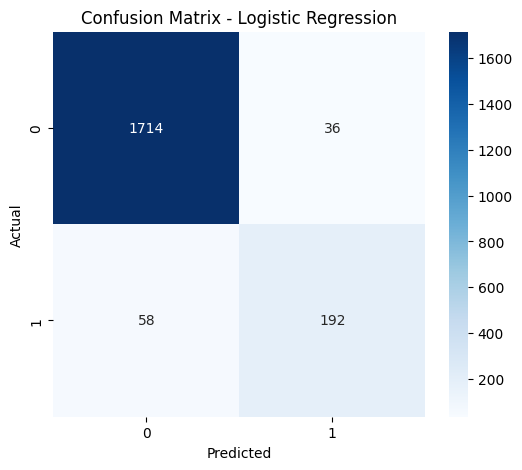


ROC-AUC Score: 0.9795291428571428

MODEL: Decision Tree

Accuracy: 0.9445

Classification Report:

              precision    recall  f1-score   support

       False       0.97      0.97      0.97      1750
        True       0.78      0.78      0.78       250

    accuracy                           0.94      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.94      0.94      0.94      2000


Confusion Matrix:

[[1695   55]
 [  56  194]]


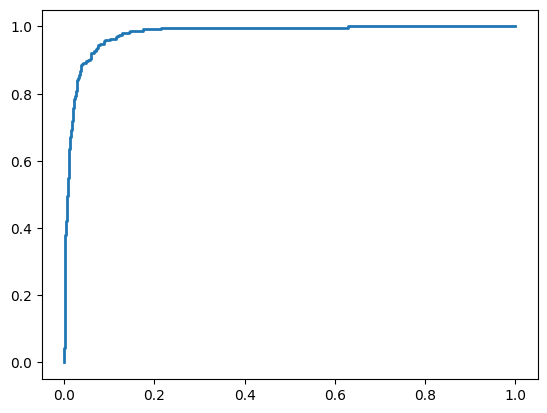

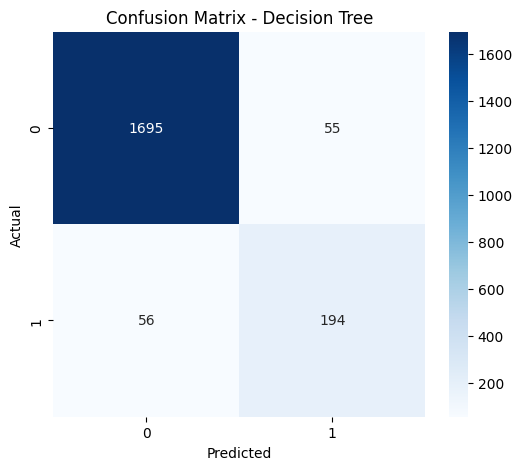


ROC-AUC Score: 0.9649051428571428

MODEL: Random Forest

Accuracy: 0.9545

Classification Report:

              precision    recall  f1-score   support

       False       0.97      0.97      0.97      1750
        True       0.82      0.82      0.82       250

    accuracy                           0.95      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.95      0.95      0.95      2000


Confusion Matrix:

[[1704   46]
 [  45  205]]


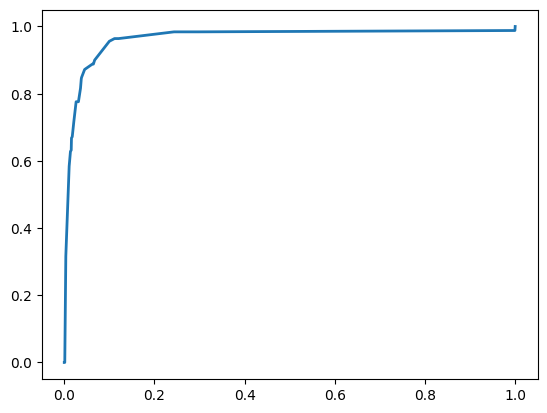

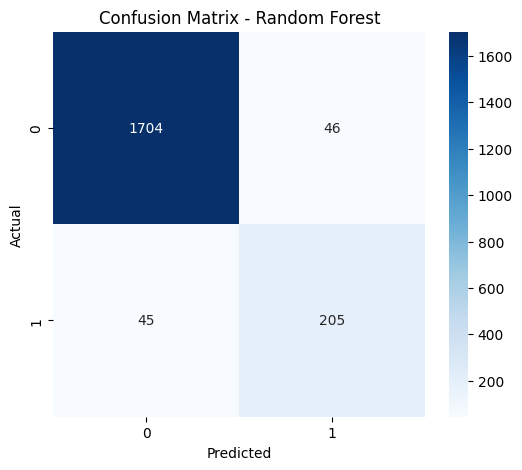


ROC-AUC Score: 0.9754731428571429

MODEL: KNN

Accuracy: 0.9135

Classification Report:

              precision    recall  f1-score   support

       False       0.92      0.99      0.95      1750
        True       0.83      0.38      0.53       250

    accuracy                           0.91      2000
   macro avg       0.88      0.69      0.74      2000
weighted avg       0.91      0.91      0.90      2000


Confusion Matrix:

[[1731   19]
 [ 154   96]]


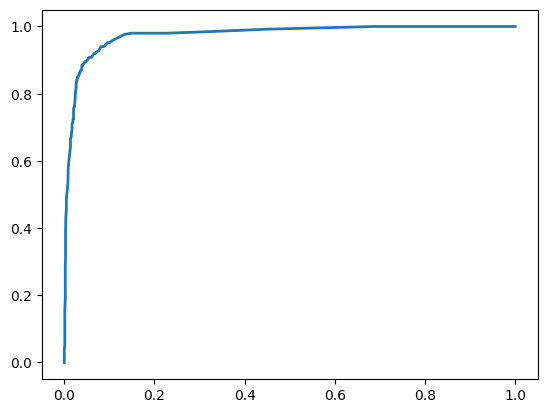

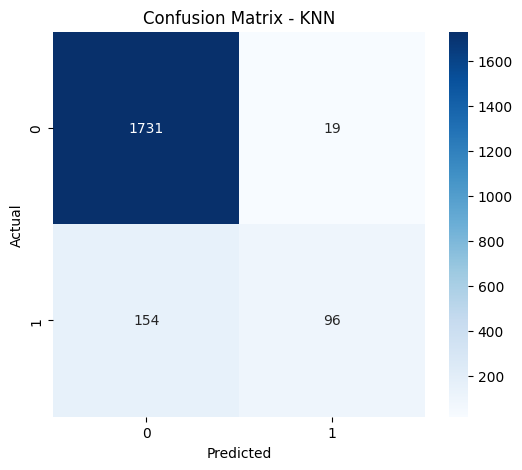


ROC-AUC Score: 0.8860868571428571

MODEL: SVM

Accuracy: 0.954

Classification Report:

              precision    recall  f1-score   support

       False       0.97      0.98      0.97      1750
        True       0.84      0.78      0.81       250

    accuracy                           0.95      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.95      0.95      0.95      2000


Confusion Matrix:

[[1714   36]
 [  56  194]]


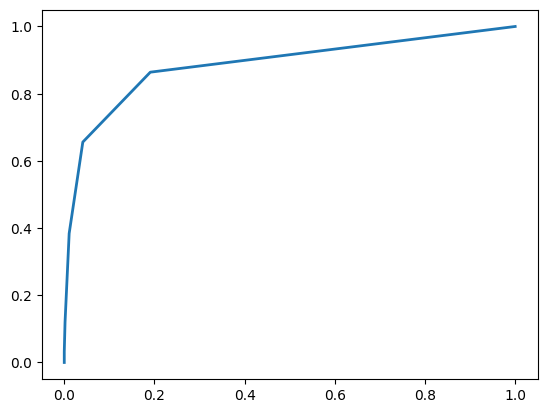

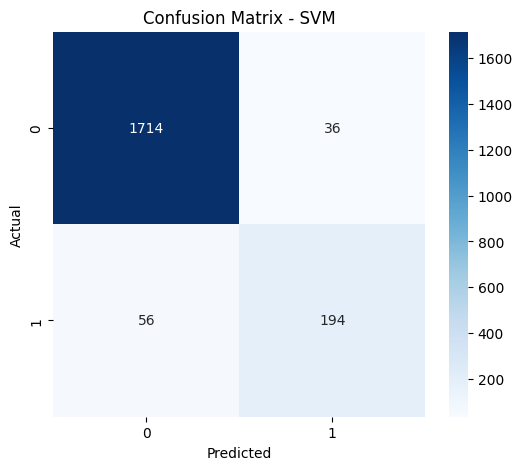


ROC-AUC Score: 0.9786628571428572

MODEL: Naive Bayes

Accuracy: 0.9555

Classification Report:

              precision    recall  f1-score   support

       False       0.98      0.97      0.97      1750
        True       0.82      0.83      0.82       250

    accuracy                           0.96      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.96      0.96      0.96      2000


Confusion Matrix:

[[1704   46]
 [  43  207]]


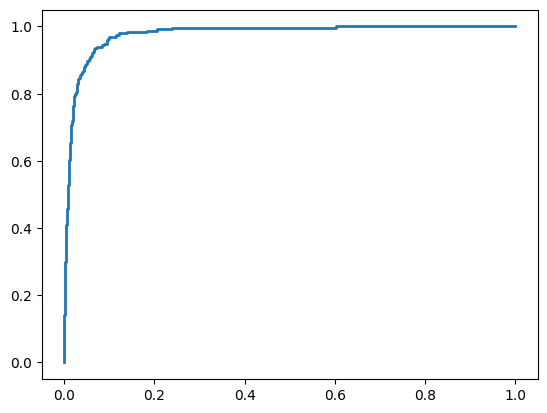

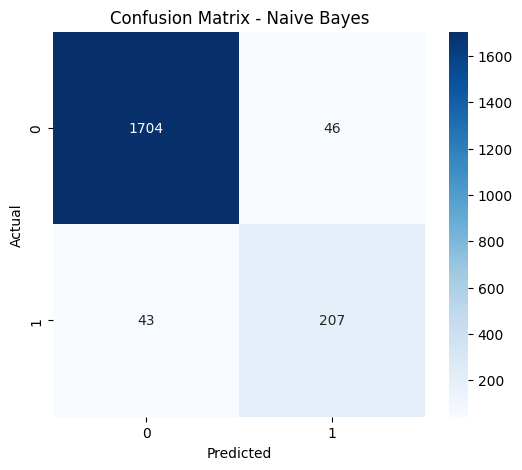


ROC-AUC Score: 0.9802354285714285


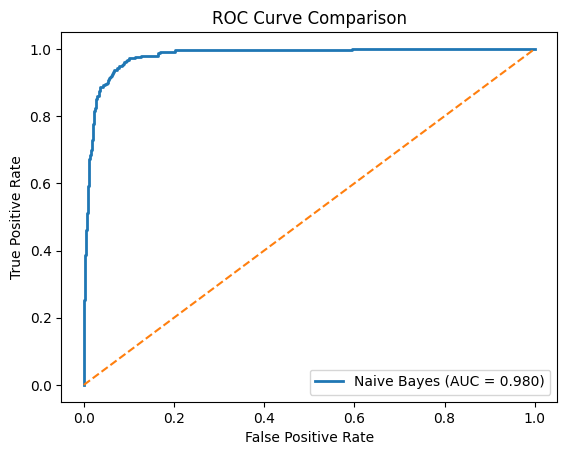


FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
0  Logistic Regression    0.9530  0.979529
1        Decision Tree    0.9445  0.964905
2        Random Forest    0.9545  0.975473
3                  KNN    0.9135  0.886087
4                  SVM    0.9540  0.978663
5          Naive Bayes    0.9555  0.980235


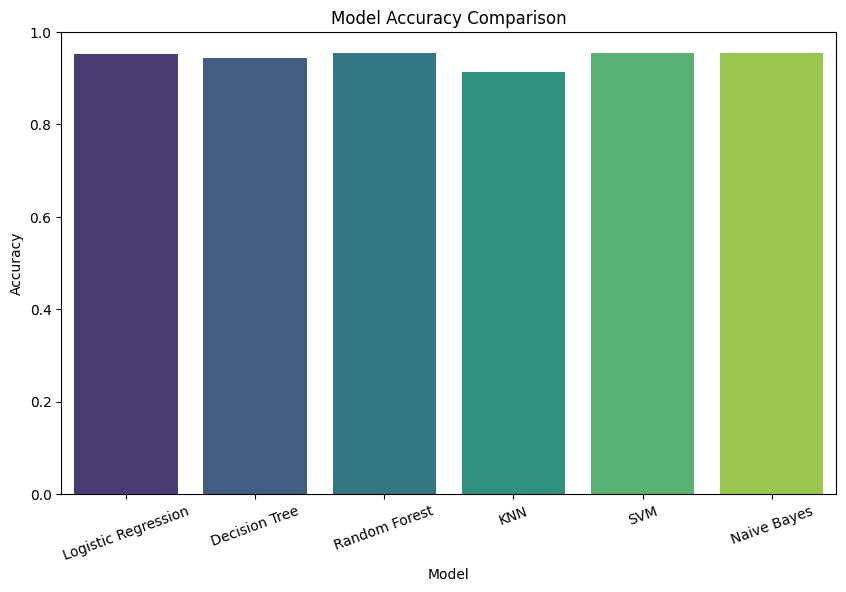

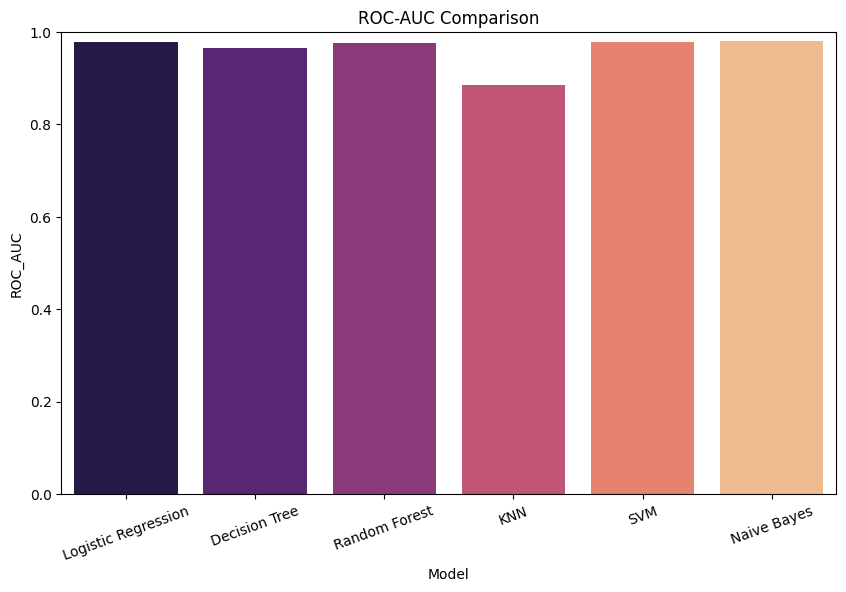


BEST MODEL
         Model  Accuracy   ROC_AUC
5  Naive Bayes    0.9555  0.980235

Top Important Features:

                           Feature  Importance
4                    anomaly_score    0.648165
10                 geo_distance_km    0.033247
8              avg_monthly_balance    0.030507
5                 account_age_days    0.029953
2                device_risk_score    0.029774
0               transaction_amount    0.029673
11        session_duration_minutes    0.029301
12      transaction_velocity_score    0.028256
9          daily_transaction_count    0.028121
3               transfer_frequency    0.025793
6            transaction_time_hour    0.020810
7     failed_transactions_last_30d    0.020439
1                   login_attempts    0.016788
14             authentication_type    0.008432
13                 payment_channel    0.007486
17              suspicious_ip_flag    0.004675
15               card_present_flag    0.004406
16  international_transaction_flag    0.004175

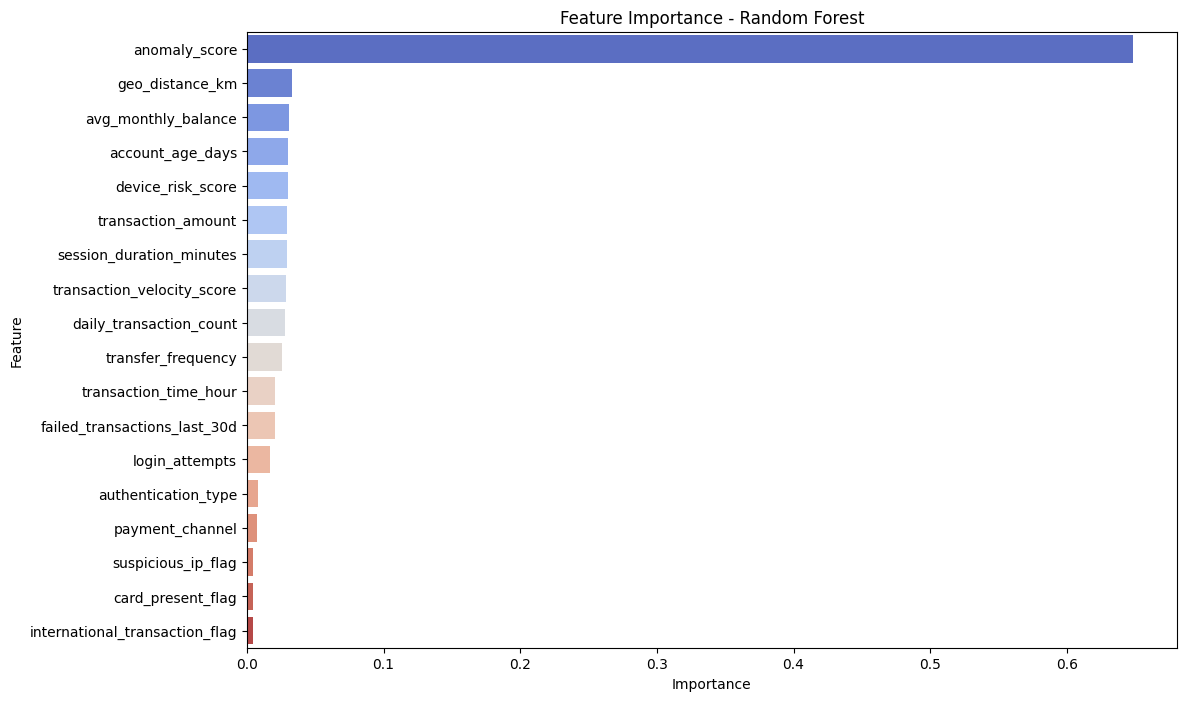


All ML Models Trained Successfully!


In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)



# fraud_flag is target
target = 'fraud_flag'

# ============================================================
# DROP UNNECESSARY COLUMN
# ============================================================

# transaction_id does not help prediction
df.drop('transaction_id', axis=1, inplace=True)

# ============================================================
# LABEL ENCODING
# ============================================================

# IMPORTANT:
# Apply encoding BEFORE scaling
# No data leakage because encoding does not learn statistics

categorical_columns = df.select_dtypes(include='object').columns

print("\nCategorical Columns:\n", categorical_columns)

# Store encoders
label_encoders = {}

for col in categorical_columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

print("\nAfter Encoding:\n")
print(df.head())

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(target, axis=1)

y = df[target]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# IMPORTANT:
# Split BEFORE scaling to avoid DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# FEATURE SCALING
# ============================================================

# IMPORTANT:
# Fit scaler ONLY on training data
# Then transform test data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    
    "Naive Bayes": GaussianNB()
}

# ============================================================
# TRAINING + EVALUATION
# ============================================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():
    
    print("\n================================================")
    print("MODEL:", name)
    print("================================================")
    
    # ============================================
    # TRAIN MODEL
    # ============================================
    
    model.fit(X_train_scaled, y_train)
    
    # ============================================
    # PREDICTION
    # ============================================
    
    y_pred = model.predict(X_test_scaled)
    
    # ============================================
    # ACCURACY
    # ============================================
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print("\nAccuracy:", accuracy)
    
    # ============================================
    # CLASSIFICATION REPORT
    # ============================================
    
    print("\nClassification Report:\n")
    
    print(classification_report(y_test, y_pred))
    
    # ============================================
    # CONFUSION MATRIX
    # ============================================
    
    cm = confusion_matrix(y_test, y_pred)
    
    print("\nConfusion Matrix:\n")
    print(cm)
    
    # Heatmap
    plt.figure(figsize=(6,5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ============================================
    # ROC AUC SCORE
    # ============================================
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print("\nROC-AUC Score:", roc_auc)
    
    # ============================================
    # ROC CURVE
    # ============================================
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )
    
    # ============================================
    # STORE RESULTS
    # ============================================
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "ROC_AUC": roc_auc
    })

# ============================================================
# FINAL ROC CURVE
# ============================================================

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n================================================")
print("FINAL MODEL COMPARISON")
print("================================================")

print(results_df)

# ============================================================
# BARPLOT OF ACCURACY
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# BARPLOT OF ROC AUC
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC',
    palette='magma'
)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print("\n================================================")
print("BEST MODEL")
print("================================================")

print(best_model.head(1))

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")
print(feature_importance)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='coolwarm'
)

plt.title("Feature Importance - Random Forest")

plt.show()


print("\nAll ML Models Trained Successfully!")

## Thank you...pls upvote!!!!!!!!!!!